In [7]:
import gpflow 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm

import sys
sys.path.append("..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP, SparseCMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

/tmp/ipykernel_4412/3816228803.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download("AAPL", start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed


/tmp/ipykernel_4412/3816228803.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft = yf.download("MSFT", start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4412/3816228803.py:18: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  aapl_normed = (aapl - aapl.mean()) / aapl.std()


[ 41.36524582  40.64349747  43.147789    46.27457428  47.43132782
  49.48483658  50.50325394  45.50944901  43.01467896  47.88930511
  48.65785217  49.98665619  48.84700394  49.62621689  49.62621689
  52.32754898  52.58950424  54.56985092  56.54537964  59.8547554
  62.53658676  63.1464653   64.42162323  64.34207916  67.49989319
  76.8600235   77.486763    69.83715057  59.86040497  68.3728714
  67.31215668  76.30851746  80.31581879  81.3818512   88.21657562
  92.52915192  94.0603714   94.70724487  95.32021332  89.97792816
  91.88226318  93.2196579  106.27856445 107.87548828 127.57196045
 111.99925232 109.86333466 120.77591705 112.60119629 111.69828033
 115.93674469 114.78915405 118.89329529 118.89329529 119.04891205
 128.25888062 123.1238327  127.29605103 128.40475464 139.22912598
 131.28349304 131.00238037 130.67126465 121.92697906 124.24902344
 124.24902344 130.71759033 141.85948181 143.22543335 143.34230042
 142.7169342  139.66835022 145.23788452 145.90232849 160.24534607
 167.4669799

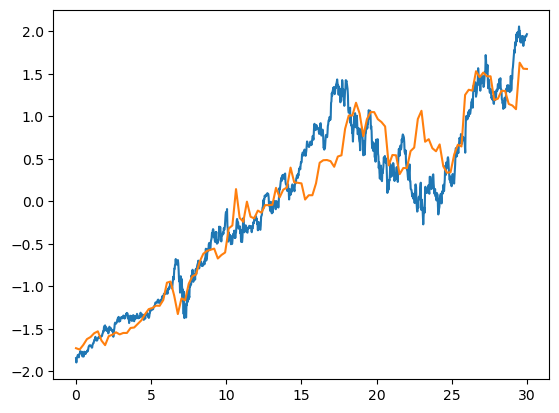

In [8]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

# here we load stock data from Yahoo Finance for the given dates
start_date = "2019-01-01"
end_date = "2024-01-01"

# retrive the data for AAPL and MSFT
aapl = yf.download("AAPL", start=start_date, end=end_date)['Close']
msft = yf.download("MSFT", start=start_date, end=end_date)['Close']
aapl.reset_index(inplace=True)
msft.reset_index(inplace=True)
msft = msft.to_numpy()[:,1].astype(np.float64)



aapl_normed = (aapl - aapl.mean()) / aapl.std()

inds = np.sort(np.random.choice(np.arange(len(aapl)), int(len(aapl)/10)))
aapl_downs = aapl.loc[inds].to_numpy()[:,1].astype(np.float64)
print(aapl_downs, msft)

# apply z normalization to the data for comparison
Y2 = ((aapl_downs - aapl_downs.mean()) / aapl_downs.std()).reshape(-1, 1)
Y1 = ((msft - msft.mean()) / msft.std()).reshape(-1, 1)
X2 = np.linspace(0, 30, len(Y2)).reshape(-1, 1)
X1 = np.linspace(0, 30, len(Y1)).reshape(-1, 1)
plt.plot(X1, Y1)
plt.plot(X2, Y2)
plt.show()


In [9]:
# Augment the input with ones or zeros to indicate the required output dimension
X = np.vstack(
    (np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2))))
)

# Augment the Y data with ones or zeros that specify a likelihood from the list of likelihoods
y = np.vstack(
    (np.hstack((Y1, np.zeros_like(Y1))), np.hstack((Y2, np.ones_like(Y2))))
)

print(X.shape, y.shape)

def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 30, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(X2, Y2, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")
    ivs = m.inducing_variable.Z.numpy() 
    plt.scatter(ivs, np.zeros_like(ivs))
    plt.legend()
    return np.mean((mu - Xtest) ** 2)


def optimize(m):
    opt = gpflow.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50, "maxiter":500})
    plt.plot(res["loss_history"])
    plt.show()

    

(1383, 2) (1383, 2)


In [10]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpflow.kernels.Matern12()
# Coregion kernel
coreg = gpflow.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
inds = np.arange(len(X))
iv_ind = np.random.choice(inds, 50)
ivs = X[iv_ind]
kern = k * coreg
print(X, y)
m = SparseCMOGP((X, y), kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpflow.likelihoods.Gaussian(), target=gpflow.likelihoods.Gaussian()))
gpflow.utilities.print_summary(m)
optimize(m)
gpflow.utilities.print_summary(m)

[[0.00000000e+00 0.00000000e+00]
 [2.38663484e-02 0.00000000e+00]
 [4.77326969e-02 0.00000000e+00]
 ...
 [2.95161290e+01 1.00000000e+00]
 [2.97580645e+01 1.00000000e+00]
 [3.00000000e+01 1.00000000e+00]] [[-1.84870514  0.        ]
 [-1.89681285  0.        ]
 [-1.83822981  0.        ]
 ...
 [ 1.62936567  1.        ]
 [ 1.55889964  1.        ]
 [ 1.55567621  1.        ]]
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value             │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0               │
├───────────────────────────────────────────

2026-04-14 17:06:12.564304: I tensorflow/core/common_runtime/executor.cc:1197] [/job:localhost/replica:0/task:0/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: indices[17] = 2 is not in [0, 2)
	 [[{{node GatherV2_18}}]]


InvalidArgumentError: Graph execution error:

Detected at node 'GatherV2_18' defined at (most recent call last):
    File "<frozen runpy>", line 198, in _run_module_as_main
    File "<frozen runpy>", line 88, in _run_code
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
      self.asyncio_loop.run_forever()
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
      self._run_once()
    File "/home/janneke/miniforge3/en

300.23482674418045

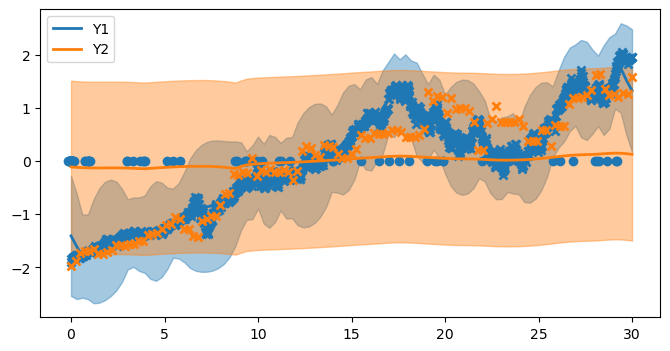

In [ ]:
plot(m)